# 02 · NLCD Tree Canopy — does canopy add lift *beyond* density?

**Intent & scope.** Step 2b of the location-basis research
(`docs/plan/location_basis_research_plan.md`). The within-county outage signal is
**rurality**; Step 2a showed town *density* captures it. This notebook onboards a
second, more physical rurality proxy — **NLCD Tree Canopy Cover** — and asks one
question: does canopy carry signal that density misses, or is density already
enough? It does **not** change pricing.

This is the *complex-source* onboarding (a 30 m national raster), so it follows
the from-scratch path: what the data is, one pixel decoded, the access method,
units/fill — then the analysis. Every output below has a written takeaway.

## Source & provenance

- **Product:** NLCD **Tree Canopy Cover (TCC)**, CONUS, 2021 (v2021-4). Each
  30 m pixel = the **percent of that pixel under tree canopy (0–100)**.
- **Access (pinned):** MRLC GeoServer **WMS `GetFeatureInfo`**, layer
  `nlcd_tcc_conus_2021_v2021-4`, at `https://www.mrlc.gov/geoserver/mrlc_display/wms`.
  We do **not** download the CONUS raster (gigabytes); we point-sample each town
  centroid. Raw samples are cached under `data/raw/nlcd_canopy/` (reproducible).
- **Client:** `analysis/lib/nlcd_canopy.py`.

In [1]:
%matplotlib inline
import sys, json
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import requests

ANALYSIS = Path.cwd().parent                      # notebooks/ -> analysis/
sys.path[:0] = [str(ANALYSIS), str(ANALYSIS / 'lib')]
import town_density_vs_size as tds                 # proven Step-2a helpers
import canopy_vs_density as cvd                     # the analysis (script-tested)
import nlcd_canopy as nc

print('product :', nc.PRODUCT)
print('WMS     :', nc.WMS)
print('layer   :', nc.LAYER)

product : NLCD Tree Canopy Cover, CONUS, 2021 (v2021-4)
WMS     : https://www.mrlc.gov/geoserver/mrlc_display/wms
layer   : nlcd_tcc_conus_2021_v2021-4


/Users/divy/code/personal/renewablesinfo_org/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### Decode one record

A `GetFeatureInfo` call returns the pixel value as `PALETTE_INDEX`. For a paletted
TCC raster that index **is the canopy percent**. Sanity check: rural/wooded
Bethany CT should read high; the value is in 0–100, and anything `>100`
(e.g. 254/255) is NoData / non-processing → treated as missing.

In [2]:
def raw_query(lat, lon, d=0.002):
    bbox = f'{lon-d},{lat-d},{lon+d},{lat+d}'
    p = dict(SERVICE='WMS', VERSION='1.1.1', REQUEST='GetFeatureInfo',
             LAYERS=nc.LAYER, QUERY_LAYERS=nc.LAYER, SRS='EPSG:4326',
             BBOX=bbox, WIDTH=5, HEIGHT=5, X=2, Y=2, INFO_FORMAT='application/json')
    return requests.get(nc.WMS, params=p, timeout=20).json()

try:
    ex = raw_query(41.4326, -72.9912)   # Bethany CT (rural, wooded)
    print(json.dumps(ex, indent=2)[:420])
    print('\n-> PALETTE_INDEX = tree-canopy %, range 0-100; >100 = NoData.')
except Exception as e:
    print('live decode skipped (using cache below):', e)

{
  "type": "FeatureCollection",
  "features": [
    {
      "type": "Feature",
      "id": "",
      "geometry": null,
      "properties": {
        "PALETTE_INDEX": 74
      }
    }
  ],
  "totalFeatures": "unknown",
  "numberReturned": 1,
  "timeStamp": "2026-06-18T02:21:11.207Z",
  "crs": null
}

-> PALETTE_INDEX = tree-canopy %, range 0-100; >100 = NoData.


### Grid, units, fill — and the one limitation to keep in mind

- **Grid/units:** 30 m pixels; value = canopy % (0–100). Fill/NoData `>100`.
- **Limitation (stated up front):** we sample the town **centroid** — one pixel —
  not the **town-mean** canopy. That is a representative interior sample, fine for
  a directional "does canopy add beyond density?" test, but a zonal mean over the
  town would be the refinement if canopy turned out to matter.

In [3]:
canopy = cvd.load_canopy()
ok = canopy['canopy_pct'].notna()
print(f'{ok.sum()}/{len(canopy)} towns have a canopy value; '
      f'{(~ok).sum()} NoData (coastal/water centroids)')
canopy.loc[ok, 'canopy_pct'].describe()[['min', '25%', '50%', '75%', 'max']].round(1)

441/445 towns have a canopy value; 4 NoData (coastal/water centroids)


min     0.0
25%    22.0
50%    68.0
75%    86.0
max    92.0
Name: canopy_pct, dtype: float64

**Takeaway:** canopy is **uniformly high** across these New England towns — most
sit well above 50%. That is the first hint that canopy may not *discriminate*
rural from urban within a county the way density does.

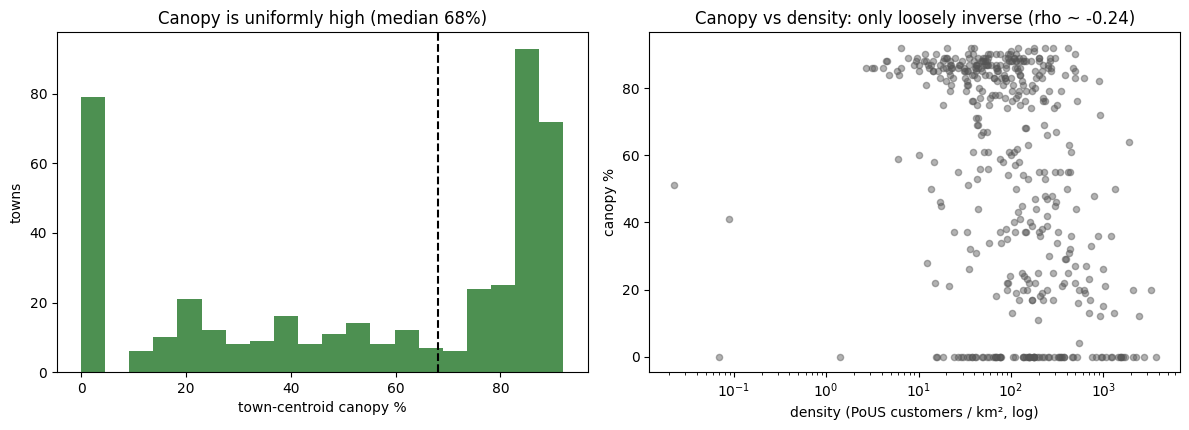

In [4]:
cells = pd.read_csv(tds.TARGET)
towns = tds.gaz.load_towns()
df4 = cvd.load_joined(cells, towns, canopy, cvd.PRIMARY_T)   # T>=4h, joined: density+canopy+rel

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
ax[0].hist(df4['canopy_pct'], bins=20, color='#2e7d32', alpha=.85)
ax[0].axvline(df4['canopy_pct'].median(), color='k', ls='--')
ax[0].set_xlabel('town-centroid canopy %'); ax[0].set_ylabel('towns')
ax[0].set_title(f'Canopy is uniformly high (median {df4.canopy_pct.median():.0f}%)')
ax[1].scatter(df4['density'], df4['canopy_pct'], s=20, alpha=.45, color='#555')
ax[1].set_xscale('log')
ax[1].set_xlabel('density (PoUS customers / km², log)'); ax[1].set_ylabel('canopy %')
ax[1].set_title('Canopy vs density: only loosely inverse (rho ~ -0.24)')
plt.tight_layout(); plt.show()

**Takeaway:** canopy and density are only *loosely* inverse — they are not the
same variable, but canopy is the blurrier one. If canopy carried independent
signal, it would show up as lift *after* controlling for density. Test that next.

In [5]:
rows = []
for T in cvd.T_HOURS:
    s = cvd.county_stats(cvd.load_joined(cells, towns, canopy, T))
    rows.append({'T_hours': T,
                 'rho_density_rel': round(s['rho_dens'], 3),
                 'rho_canopy_rel': round(s['rho_canopy'], 3),
                 'rho_canopy_density': round(s['rho_canopy_dens'], 3),
                 'partial_canopy_given_density': round(s['partial_canopy'], 3)})
res = pd.DataFrame(rows)
res

,T_hours,rho_density_rel,rho_canopy_rel,rho_canopy_density,partial_canopy_given_density
0,1,-0.411,0.116,-0.241,0.002
1,2,-0.414,0.090,-0.241,-0.026
2,4,-0.348,0.015,-0.241,-0.119
3,8,-0.299,-0.019,-0.241,-0.042


**How to read the table.** All are *median within-county Spearman* correlations
with the relative outage rate:
- `rho_density_rel` — density's signal (negative: denser → below county average).
- `rho_canopy_rel` — canopy's own signal (positive would mean wooded → worse).
- `rho_canopy_density` — collinearity between the two proxies.
- `partial_canopy_given_density` — **the key number**: canopy's correlation with
  the relative *after removing density*. ≈ 0 ⇒ density already captures it.

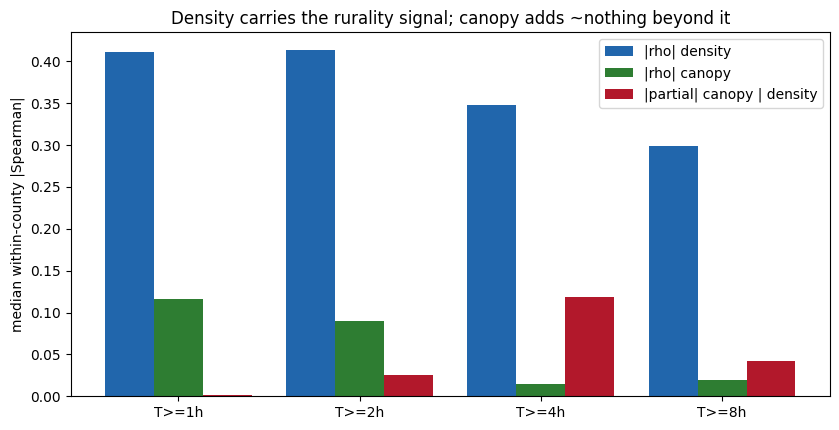

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 4.4))
x = np.arange(len(res)); w = 0.27
ax.bar(x - w, res['rho_density_rel'].abs(), w, label='|rho| density', color='#2166ac')
ax.bar(x,     res['rho_canopy_rel'].abs(), w, label='|rho| canopy', color='#2e7d32')
ax.bar(x + w, res['partial_canopy_given_density'].abs(), w,
       label='|partial| canopy | density', color='#b2182b')
ax.set_xticks(x); ax.set_xticklabels([f'T>={t}h' for t in res['T_hours']])
ax.set_ylabel('median within-county |Spearman|')
ax.set_title('Density carries the rurality signal; canopy adds ~nothing beyond it')
ax.legend(); plt.tight_layout(); plt.show()

## Headline — density is the parsimonious answer

**Centroid tree canopy does not add lift beyond density.** Density's within-county
correlation with the relative is strong and stable (|rho| ~0.30–0.41); canopy's
own correlation is weak (|rho| ~0.02–0.12); and **once density is controlled for,
canopy's partial correlation is ~0** (even slightly negative at T≥4h).

**Why:** in leafy New England, canopy *saturates* (median 68%), so it cannot
separate a rural town from a semi-urban one *within the same county* — whereas
density (customers / km²) separates them cleanly. Canopy is the mechanism (tree
contact), but density is the better *discriminator* here.

**Decision:** build the within-county location-basis modifier on **density alone**
for this region — one simple, explainable feature. We do **not** need the canopy
raster pipeline for Gen-1 New England.

## Gotchas & cautions

- **Centroid ≠ town-mean canopy.** A single pixel is a weak canopy estimate; a
  zonal mean *might* do better. But the bar is high — density already explains
  the rurality signal, and canopy's partial contribution is ~0, so a better
  canopy measure is unlikely to overturn the conclusion *for New England*.
- **Region-specific.** This is a NE result. In a low-tree region (e.g. parts of
  TX/the West) canopy saturates low and **land-cover type or wind/terrain** may
  matter more than density. Re-test per region; do not generalize the "density
  alone" rule nationally yet.
- **One quiet season** (CT/MA/RI, Jan–Mar 2019). Provisional until replicated.
- **Cell exposure, not premise** (inherited ceiling): the town→address last mile
  still needs live geometry / meter data.

## Carried-forward artifact & decision

- **Artifact:** `data/raw/nlcd_canopy/town_canopy.csv` (per-town centroid canopy),
  joinable to `analysis/outputs/town_density_features.csv`.
- **Decision for the modifier:** proceed with a **density-based** mean-1 frequency
  relativity (Step 2a/2b finding). Canopy is parked, not deleted — revisit via
  zonal mean and in non-NE regions.

### Cross-references
- Density vs size (Step 2b): `docs/extra/location_features/docs/01_findings.md`
- Target build + rurality (Steps 1–2a): `docs/extra/poweroutage_us/docs/06_findings.md` sets 6–7
- Design + lane corrections: `docs/dicsscssion/location_aware_outage_pricing/03_location_basis_risk_design.md`
- Research plan: `docs/plan/location_basis_research_plan.md`